In [1]:
import pandas as pd

# Load balanced dataset 
balanced_df = pd.read_csv("addbalanced_data.csv")

# Assuming your dataset has 'Review' and 'Rating' columns
texts = balanced_df["Review"].astype(str).tolist()
labels = balanced_df["Rating"].astype(int).tolist()

Encode labels

In [2]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)  # Converts labels to 0,1,2,...

num_classes = len(label_encoder.classes_)
print("Classes:", label_encoder.classes_)

Classes: [1 2 3 4 5]


Tokenization with keras

In [3]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [4]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_NUM_WORDS = 20000  # Keep top 20k words
MAX_SEQUENCE_LENGTH = 200  # Pad/truncate reviews to 200 words

tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

# Convert text to sequences
sequences = tokenizer.texts_to_sequences(texts)

# Pad sequences to same length
X = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

Train-test-split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, labels_encoded, test_size=0.2, random_state=42, stratify=labels_encoded
)

Prepare Embedding Matrix (Using GloVe)

In [6]:
import numpy as np

EMBEDDING_DIM = 100
embedding_index = {}

# Load GloVe embeddings
with open("glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coeffs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coeffs

# Create embedding matrix
word_index = tokenizer.word_index
embedding_matrix = np.zeros((MAX_NUM_WORDS, EMBEDDING_DIM))

for word, i in word_index.items():
    if i < MAX_NUM_WORDS:
        embedding_vector = embedding_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

In [7]:
import joblib

#joblib.dump(tokenizer, "tokenizer_lstm.pkl")
#joblib.dump(label_encoder, "label_encoder_lstm.pkl")
#np.save("embedding_matrix.npy", embedding_matrix)

import required libraries

In [8]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import joblib

Convert labels to categorical (one-hot encoding)

In [9]:
# Convert integer labels to one-hot encoded format
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

Build the LSTM model

In [10]:
model = Sequential()
model.add(
    Embedding(
        input_dim=MAX_NUM_WORDS,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_SEQUENCE_LENGTH,
        trainable=False  # Freeze GloVe embeddings
    )
)
model.add(LSTM(128, return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(64, activation="relu"))
model.add(Dropout(0.3))
model.add(Dense(num_classes, activation="softmax"))  # Output layer

C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Compile the model

In [11]:
model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [12]:
#early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

Training

In [13]:
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 560s 89ms/step - accuracy: 0.1983 - loss: 1.6098 - val_accuracy: 0.2000 - val_loss: 1.6095
Epoch 2/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 580s 93ms/step - accuracy: 0.2005 - loss: 1.6096 - val_accuracy: 0.2000 - val_loss: 1.6095
Epoch 3/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 586s 94ms/step - accuracy: 0.1992 - loss: 1.6096 - val_accuracy: 0.2000 - val_loss: 1.6095
Epoch 4/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 589s 94ms/step - accuracy: 0.1991 - loss: 1.6096 - val_accuracy: 0.2000 - val_loss: 1.6095
Epoch 5/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 600s 96ms/step - accuracy: 0.2003 - loss: 1.6095 - val_accuracy: 0.2000 - val_loss: 1.6096
Epoch 6/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 603s 96ms/step - accuracy: 0.2000 - loss: 1.6095 - val_accuracy: 0.2000 - val_loss: 1.6096
Epoch 7/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 611s 98ms/step - accuracy: 0.2003 - loss: 1.6095 - val_accuracy: 0.2000 - val_loss: 1.6095


Evaluate

In [14]:
loss, accuracy = model.evaluate(X_test, y_test_cat)
print(f"Test Accuracy: {accuracy:.4f}")

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.2000 - loss: 1.6095
Test Accuracy: 0.2000


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import tensorflow as tf

# Convert labels to one-hot vectors
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

# Build LSTM model
model = Sequential([
    Embedding(
        input_dim=MAX_NUM_WORDS,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_SEQUENCE_LENGTH,
        trainable=True  # Fine-tune GloVe embeddings
    ),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

# Compile
optimizer = Adam(learning_rate=1e-3)
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

# Print summary
model.summary()

# Train
history = model.fit(
    X_train, y_train_cat,
    validation_split=0.1,
    epochs=15,
    batch_size=64,  # GPU-friendly batch size
    callbacks=[early_stop, lr_reduce],
    verbose=1
)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print("Test Accuracy: {:.4f}".format(test_acc))


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │       2,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 1018s 360ms/step - accuracy: 0.4861 - loss: 1.1564 - val_accuracy: 0.5207 - val_loss: 1.0724 - learning_rate: 0.0010
Epoch 2/15
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 922s 328ms/step - accuracy: 0.5347 - loss: 1.0572 - val_accuracy: 0.5276 - val_loss: 1.0627 - learning_rate: 0.0010
Epoch 3/15
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 963s 342ms/step - accuracy: 0.5563 - loss: 1.0164 - val_accuracy: 0.5268 - val_loss: 1.0622 - learning_rate: 0.0010
Epoch 4/15
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 820s 292ms/step - accuracy: 0.5760 - loss: 0.9770 - val_accuracy: 0.5302 - val_loss: 1.0808 - learning_rate: 0.0010
Epoch 5/15
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.6026 - loss: 0.9269
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 827s 294ms/step - accuracy: 0.5967 - loss: 0.9366 - val_accuracy: 0.5279 - val_loss: 1.1057 - learning_rate: 0.0010
Epoch 6/15
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 843s 300ms/s

In [19]:
model.save("lstm_balanced_review_model.h5")

Evaluate

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 41ms/step
Accuracy:  0.5311
Precision: 0.5309
Recall:    0.5311
F1 Score:  0.5232


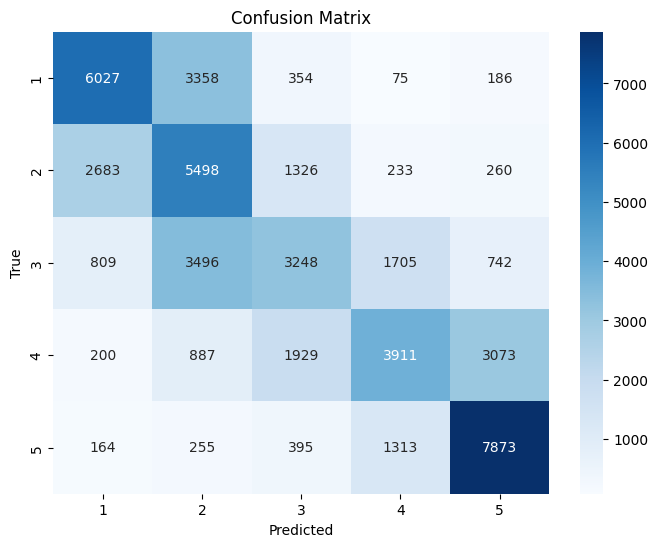

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predict class probabilities
y_pred_probs = model.predict(X_test)
# Convert to class predictions
y_pred = y_pred_probs.argmax(axis=1)
y_true = y_test  # Already in encoded form

# Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

# Print
print("Accuracy:  {:.4f}".format(accuracy))
print("Precision: {:.4f}".format(precision))
print("Recall:    {:.4f}".format(recall))
print("F1 Score:  {:.4f}".format(f1))


# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()